In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse.linalg import LinearOperator, lsqr
import scipy
import time
from scipy.interpolate import lagrange, RegularGridInterpolator
from ader_dg_transport.utils import gll, lagrange1st

from ader_dg_transport.dg_2D import wave_dg_2D, wave_dg_adjoint_2D, wave_dg_optimizer_2D

import importlib
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
data = np.load('marmousi_Ip_model.npy')

In [3]:
marmousi = data[0, 3_500:3_500 + data.shape[2]].transpose()

xs_ = np.linspace(0, 17_000, data.shape[1])[:marmousi.shape[1]]
xs_ -= xs_.min()
ys_ = np.linspace(0, 3_500, data.shape[2])
# xs, ys = np.meshgrid(xs, ys)

interp = RegularGridInterpolator((ys_, xs_), marmousi, method='nearest')

In [ ]:
smooth_marmousi = 

In [4]:
xlim = xs_.max()
ylim = ys_.max()

nx = 10
ny = 10

c = marmousi.max()

poly_order = 3

dx = xlim / nx
cfl = 0.5 / (2 * poly_order + 1)
dt = cfl * dx / c

tend = 1.0

nsteps = int(tend / dt) + 1
dt = tend / nsteps

In [5]:
f0 = 1 / 0.04
sig = 500

def F(t):
    return (2 * np.pi * f0)**2 * ((4 * np.pi * (f0 * t - 1)**2) - 1) * np.exp(-2 * np.pi * (f0 * t - 1)**2)


def f(x, y, t):

    
    out = np.zeros(t.shape + (3,) + x.shape)

    out[:, 1] = F(t)[:, None, None, None, None] * np.exp(-((x - 0.5 * xlim)**2 + (y - 0.8 * ylim)**2) / sig**2)[None]
    return out



# ts = np.linspace(0, 3 / f0, 100)
# forcing = f(xs, ys, ts)


# ts = np.linspace(0, 3 / f0, 100)
# plt.plot(ts * f0, F(ts))

# ts = np.linspace(0, 3 / f0, int((3 / f0) / dt))
# plt.plot(ts * f0, F(ts), '*')

# plt.figure()
# plt.tricontourf(xs.ravel(), ys.ravel(), f(xs, ys, 1 / f0)[0].ravel())

In [6]:
# # 
# # 

# for p in range(2, 6):

#     xis_, _ = gll(p, iterative=True)
#     D = lagrange1st(p, xis_).transpose().copy()
    
#     print('template<>')
#     print(f'struct DGConstants<{p+1}>')
#     print('{')
#     print(f'    static constexpr std::array<std::array<double,{p+1}>,{p+1}> D =', '{{')

#     for i in range(p+1):
        
#         print('        {{', ', '.join(str(x) for x in D[i]), '}},')
#     print('    }};')
#     print('};')
    
#     print()
# #         {{ -5,  6, -1,  0,  0,  0 }},
# #         {{ -1,  0,  1,  0,  0,  0 }},
# #         {{  0, -1,  0,  1,  0,  0 }},
# #         {{  0,  0, -1,  0,  1,  0 }},
# #         {{  0,  0,  0, -1,  0,  1 }},
# #         {{  0,  0,  0,  1, -6,  5 }}
# #     }};
# # };

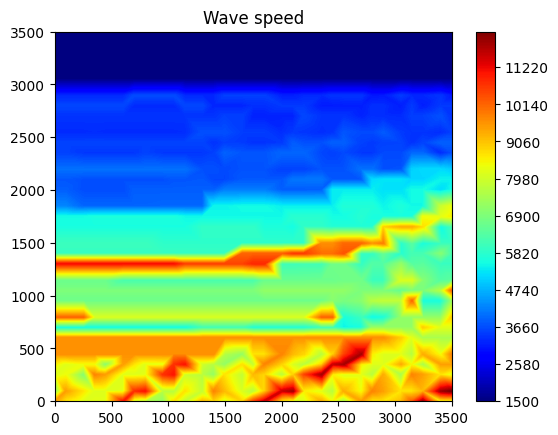

In [7]:
importlib.reload(wave_dg_2D)
importlib.reload(wave_dg_adjoint_2D)

forward_solver = wave_dg_2D.WaveDG2D(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)
forward_solver.y_periodic = False
forward_solver.x_periodic = False


adjoint_solver = wave_dg_adjoint_2D.WaveAdjointDG2D(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)
adjoint_solver.y_periodic = forward_solver.y_periodic
adjoint_solver.x_periodic = forward_solver.x_periodic

xs = forward_solver.xs
ys = forward_solver.ys

pts = np.vstack([3500 - ys.ravel(), xs.ravel()]).transpose()
c_exact = interp(pts).reshape(forward_solver.c.shape)

r2 = (xs - (xlim / 2))**2 + (ys - 0.8 * ylim)**2
h0 = np.exp(-r2 / 500**2)

# # forward_solver.c[forward_solver.xs > 5] = 0.5
forward_solver.c[:] = c_exact
adjoint_solver.c[:] = forward_solver.c

plt.title(f'Wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c_exact.ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Get target state

CPU times: user 247 ms, sys: 7.09 ms, total: 254 ms
Wall time: 289 ms


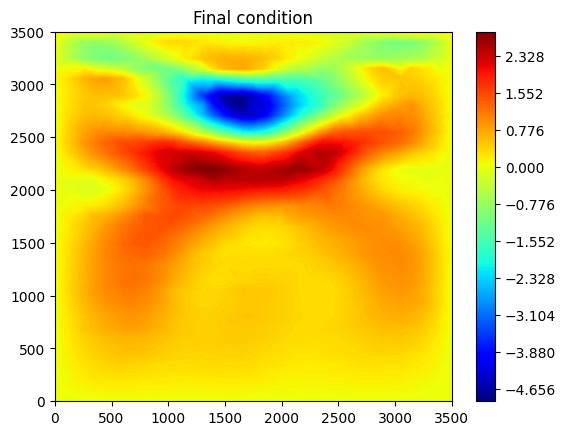

In [8]:
%%time
forward_solver.time = 0.0
forward_solver.state[:] = 0.0
# forward_solver.state[0][:] = h0
# forward_solver.state[2][:] = h0
forward_solver.cpp = True

ic_state = np.copy(forward_solver.state)

for _ in range(nsteps):

    ts = np.array([forward_solver.time] * 4)
    ts[1] += 0.5 * dt
    ts[2] += dt
    ts[3] += 0.5 * dt
    
    forward_solver.time_step(forcing=f(xs, ys, ts))

target_state = np.copy(forward_solver.state)
c_true = np.copy(forward_solver.c)

plt.title(f'Final condition')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.state[2].ravel(), levels=1000, cmap='jet')
plt.colorbar()

CPU times: user 250 ms, sys: 9.91 ms, total: 260 ms
Wall time: 296 ms


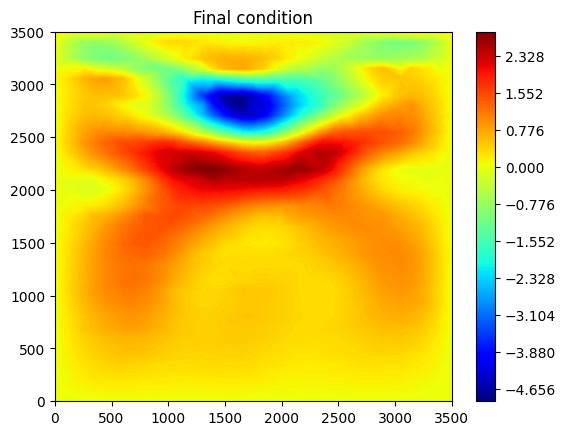

In [9]:
%%time
forward_solver.time = 0.0
forward_solver.state[:] = 0.0
# forward_solver.state[0][:] = h0
# forward_solver.state[2][:] = h0
forward_solver.cpp = True

ic_state = np.copy(forward_solver.state)

for _ in range(nsteps):

    ts = np.array([forward_solver.time] * 4)
    ts[1] += 0.5 * dt
    ts[2] += dt
    ts[3] += 0.5 * dt
    
    forward_solver.time_step(forcing=f(xs, ys, ts))

target_state = np.copy(forward_solver.state)
c_true = np.copy(forward_solver.c)

plt.title(f'Final condition')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.state[2].ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Optimize

In [10]:
importlib.reload(wave_dg_optimizer_2D)

optimizer = wave_dg_optimizer_2D.WaveDGOptimizer2D(
    forward_solver, adjoint_solver, ic_state=ic_state, target_state=target_state, nsteps=nsteps, forcing_func=f
)

In [15]:
# c0 = np.ones_like(c_true)
c0 = c_true.mean(axis=(0, 2), keepdims=True) * np.ones_like(np.ones_like(c_true))

In [16]:
dc = np.random.random(c_true.shape)

In [17]:
# check accuracy of gradient
eps = 1e-7
dcost = optimizer.cost_function(c0 + 0.5 * eps * dc) - optimizer.cost_function(c0 - 0.5 * eps * dc)
dcostdc = optimizer.jac_function(c0)
print(dcost)
print((dcostdc * dc.ravel() * eps).sum())

0.0006664448883384466
0.0006664506148970315


In [19]:
# check exact adjoints
v1 = np.random.random(forward_solver.c.shape)
v2 = np.random.random(forward_solver.state.shape)

In [20]:
out1 = optimizer.G_matvec(v1)
out2 = optimizer.G_rmatvec(v2)

print((v1.ravel() * out2).sum())
print((v2.ravel() * out1).sum())

-0.042779541827743045
-0.04277954182774309


In [186]:
error = optimizer.error(c0, fill_gradient=True)
c_error = c0 - c_true

final_state_norm = 0.5*forward_solver.norm(*forward_solver.get_vars(target_state))**2
c_norm = 0.5 * (c_true * c_true * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25

print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c0)
print('||dedc||:', np.linalg.norm(dedc))

Final state error: 0.1366446755453861
Wave speed (c) error: 0.022830767860595454
||dedc||: 1001.1913249973168


Final state error: 0.0006937917125746807
Wave speed (c) error: 0.017840626662862343
||dedc||: 6.800530656174141
CPU times: user 1min 53s, sys: 2min 7s, total: 4min 1s
Wall time: 1min 14s


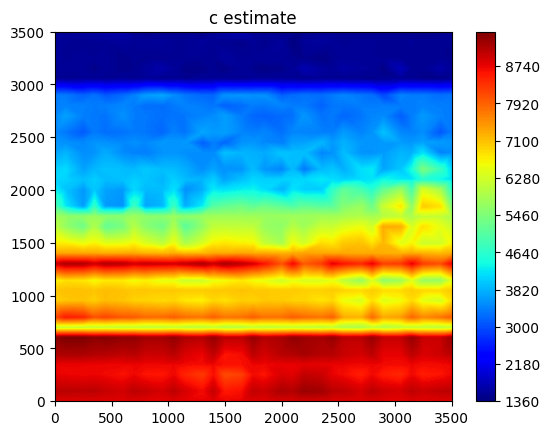

In [187]:
%%time
result = scipy.optimize.minimize(
    optimizer.cost_function, c0.ravel(), jac=optimizer.jac_function, method='L-BFGS-B', options=dict(maxiter=100)
)

c_est = result.x.reshape(forward_solver.c.shape)
error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.003403590969524006
Wave speed (c) error: 0.008702768618282652
||dedc||: 203.8137832793856
CPU times: user 39.4 s, sys: 649 ms, total: 40 s
Wall time: 40.3 s


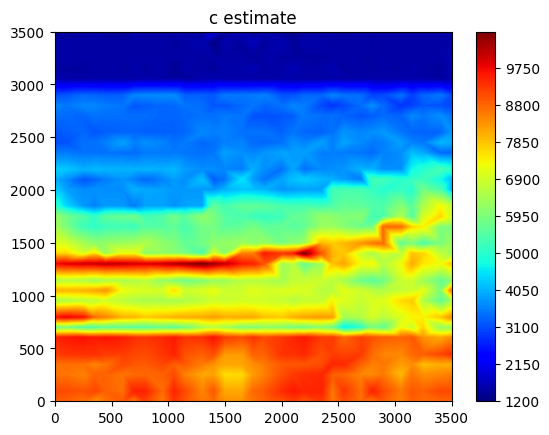

In [188]:
%%time
c_est = optimizer.optimization_step(c_est, maxiter=100)

error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.0009239725048449313
Wave speed (c) error: 0.0036466870737887676
||dedc||: 96.75534485065783
CPU times: user 1min 17s, sys: 1.3 s, total: 1min 19s
Wall time: 1min 19s


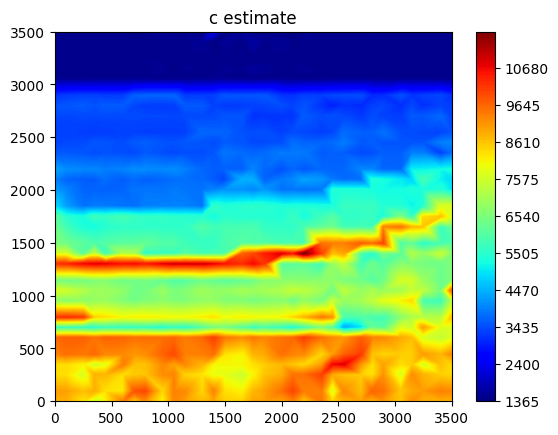

In [189]:
%%time
c_est = optimizer.optimization_step(c_est, maxiter=200)

error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 4.2578489626297424e-05
Wave speed (c) error: 0.0022230687871795736
||dedc||: 20.91056362585406
CPU times: user 1min 18s, sys: 1.16 s, total: 1min 19s
Wall time: 1min 19s


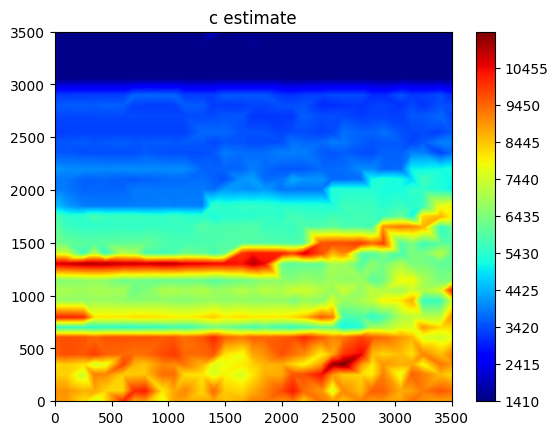

In [190]:
%%time
c_est = optimizer.optimization_step(c_est, maxiter=200)

error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 8.03782326309141e-06
Wave speed (c) error: 0.0014920385513776016
||dedc||: 8.428926056470937
CPU times: user 1min 18s, sys: 1.74 s, total: 1min 20s
Wall time: 1min 20s


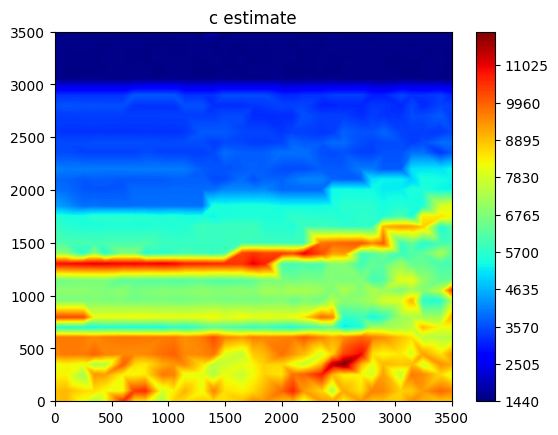

In [191]:
%%time
c_est = optimizer.optimization_step(c_est, maxiter=200)

error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

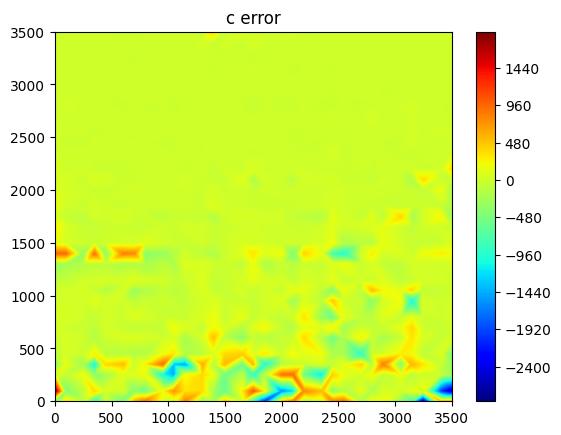

In [192]:
plt.title(f'c error')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_error).ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Optimize

In [ ]:
v1 = np.random.random(forward_solver.c.shape)
v2 = np.random.random(forward_solver.state.shape)

out1 = G_matvec(v1)
out2 = G_rmatvec(v2)

print((v1.ravel() * out2).sum())
print((v2.ravel() * out1).sum())

# Test adjoint

In [10]:
v1 = np.random.random(forward_solver.state.shape)
v2 = np.random.random(forward_solver.state.shape)

In [11]:
forward_solver.cpp = True
adjoint_solver.cpp = True

tmp = np.zeros_like(forward_solver.state)
forward_solver.solve(v1, tmp)
out1 = adjoint_solver.integrate(v2 * tmp)

adjoint_solver.solve(v2, tmp)
out2 = adjoint_solver.integrate(v1 * tmp)

print(out1)
print(out2)

1.4871387521134236
1.4871387521134256


In [12]:
forward_solver.cpp = True
adjoint_solver.cpp = True

forward_solver.state[:] = v1
for _ in range(nsteps):
    forward_solver.time_step()
out1 = forward_solver.integrate(v2 * forward_solver.state)

adjoint_solver.state[:] = v2
for _ in range(nsteps):
    adjoint_solver.time_step()
out2 = adjoint_solver.integrate(v1 * adjoint_solver.state)

print(out1)
print(out2)

75.32145007301754
75.3214500730178


# Test gradient

In [13]:
du0 = np.random.random(forward_solver.state.shape)

In [14]:
reconstructed_ic = np.ones_like(target_ic)
forward_solver.state[:] = reconstructed_ic
for _ in range(nsteps):
    forward_solver.time_step()

error0_ = forward_solver.state - target_state
error0 = 0.5*forward_solver.norm(*forward_solver.get_vars(error0_))**2

In [15]:
eps = 1e-4
forward_solver.state[:] = reconstructed_ic - 0.5 * eps * du0
for _ in range(nsteps):
    forward_solver.time_step()

error1_ = forward_solver.state - target_state
error1 = 0.5*forward_solver.norm(*forward_solver.get_vars(error1_))**2

In [16]:
eps = 1e-4
forward_solver.state[:] = reconstructed_ic + 0.5 * eps * du0
for _ in range(nsteps):
    forward_solver.time_step()

error2_ = forward_solver.state - target_state
error2 = 0.5*forward_solver.norm(*forward_solver.get_vars(error2_))**2

In [17]:
print(error2 - error1)

0.014738131891107287


In [18]:
weights = forward_solver.weights_2D[None, None, None] * forward_solver.dx *  forward_solver.dy * 0.25
print((error0_ * (error2_ - error1_) * weights).sum())

0.014738131891073003


In [19]:
eps = 1e-4
adjoint_solver.state[:] = error0_
for _ in range(nsteps):
    adjoint_solver.time_step()

weights = forward_solver.weights_2D[None, None, None] * forward_solver.dx *  forward_solver.dy * 0.25
print((adjoint_solver.state * eps * du0 * weights).sum())

0.014738131891356922


# Vary c

## Check difference

In [20]:
c0 = np.ones_like(forward_solver.c)


In [21]:
# get gradient data
history_data = np.zeros((nsteps, 4) + forward_solver.state.shape)
forward_solver.state[:] = target_ic
forward_solver.c[:] = c0
adjoint_solver.c[:] = c0

for i in range(nsteps):
    forward_solver.time_step(history_data=history_data[i])

error = forward_solver.state - target_state

In [22]:
dc = np.random.random(c_true.shape)

In [23]:
eps = 1e-6

In [24]:
# vary c and calculate difference
forward_solver.c[:] = c0 - 0.5 * eps * dc
forward_solver.state[:] = target_ic

for _ in range(nsteps):
    forward_solver.time_step()

state1 = np.copy(forward_solver.state)
error1 = 0.5*forward_solver.norm(*forward_solver.get_vars(state1 - target_state))**2

forward_solver.c[:] = c0

In [25]:
forward_solver.c[:] = c0 + 0.5 * eps * dc
forward_solver.state[:] = target_ic

for _ in range(nsteps):
    forward_solver.time_step()

state2 = np.copy(forward_solver.state)
error2 = 0.5*forward_solver.norm(*forward_solver.get_vars(state2 - target_state))**2

forward_solver.c[:] = c0

In [26]:
dstate = state2 - state1

In [27]:
forward_solver.state[:] = 0.0

for i in range(nsteps):
    forward_solver.time_step(forcing=history_data[i] * eps * dc[None, None])

diff_est = np.copy(forward_solver.state)

In [28]:
print(np.linalg.norm(diff_est - dstate) / np.linalg.norm(dstate))

1.8927517712800025e-10


In [29]:
print(error2 - error1)

4.092237712027824e-06


In [30]:
print((error * (state2 - state1) * weights).sum())

4.092237711979067e-06


In [31]:
print((error * forward_solver.state * weights).sum())

4.092237712004551e-06


## Get adjoint

In [32]:
adjoint_data = np.zeros((nsteps, 4) + forward_solver.state.shape)
adjoint_solver.state[:] = error
for i in range(nsteps):
    adjoint_solver.time_step(stage_data=adjoint_data[i])

tmp = (adjoint_data[::-1, ::-1] * history_data).sum(axis=(0, 2)) * 0.5 * adjoint_solver.dt
dedc = (tmp[3] + tmp[2] * (1 / 3) + tmp[1] + tmp[0]) * weights[0]

print((dedc * dc * eps).sum())

4.092237712004557e-06


## Try and optimize

In [33]:
def get_error(c_in, target_state, ic_state, fill_gradient=False):

    forward_solver.state[:] = ic_state
    forward_solver.c[:] = c_in
    adjoint_solver.c[:] = forward_solver.c
    for i in range(nsteps):
        if fill_gradient:
            forward_solver.time_step(history_data=history_data[i])
        else:
            forward_solver.time_step()
       
    error = forward_solver.state - target_state

    return error

In [34]:
W = adjoint_solver.weights_2D[None, None, None] * adjoint_solver.dy * adjoint_solver.dx * 0.25
M = adjoint_solver.weights_2D[None, None] * adjoint_solver.dy * adjoint_solver.dx * 0.25

W_half = np.sqrt(W)
M_half = np.sqrt(M)

W_half_inv = 1 / W_half
M_half_inv = 1 / M_half

In [35]:
def G_matvec(dc_vec):
    # 1) reshape u0

    n = forward_solver.poly_order + 1

    dc = dc_vec.reshape((nx, ny, n, n)) * M_half_inv
    forward_solver.state[:] = 0.0
    for i in range(nsteps):
        forward_solver.time_step(forcing=history_data[i] * dc[None, None])
        
    return np.copy(forward_solver.state * W * W_half_inv).ravel()
    # return np.copy(forward_solver.state * W).ravel()


def G_rmatvec(y_vec):
    # y_vec has size m = Nrec*Nt
    data = y_vec.reshape(adjoint_solver.state.shape) * W_half_inv

    adjoint_solver.state[:] = data

    n = forward_solver.poly_order + 1
    out = np.zeros((nx, ny, n, n))
    
    for i in range(nsteps):
        
        adjoint_solver.time_step(stage_data=adjoint_data[i])

    tmp = (adjoint_data[::-1, ::-1] * history_data).sum(axis=(0, 2)) * 0.5 * adjoint_solver.dt
    dedc = (tmp[3] + tmp[2] * (1 / 3) + tmp[1] + tmp[0]) * weights[0]
    
    return (dedc * M_half_inv).ravel()
    # return (dedc).ravel()

In [36]:
G = LinearOperator(
    shape=(target_state.size, c0.size),
    matvec=G_matvec,
    rmatvec=G_rmatvec,
    dtype=np.float64
)


def optimization_step(c_in, target_state, ic_state, maxiter=10):

    error = get_error(c_in, target_state, ic_state, fill_gradient=True)

    b = (-error * W_half).ravel()
    
    result = lsqr(G, b, atol=1e-10, btol=1e-10, iter_lim=maxiter)
    dc = result[0].reshape(c0.shape) * M_half_inv

    c_out = c_in + dc

    return c_out

In [37]:
def cost_function(c_in):
    c_in = c_in.reshape(c0.shape)
    error = get_error(c_in, target_state, target_ic, fill_gradient=False)
    return 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2


def jac_function(c_in):
    c_in = c_in.reshape(forward_solver.c.shape)
    error = get_error(c_in, target_state, target_ic, fill_gradient=True)

    dedc = G_rmatvec(error * W_half).reshape(forward_solver.c.shape) * M_half

    return dedc.ravel()

In [38]:
# dedc.shape

In [39]:
v1 = np.random.random(forward_solver.c.shape)
v2 = np.random.random(forward_solver.state.shape)

out1 = G_matvec(v1)
out2 = G_rmatvec(v2)

print((v1.ravel() * out2).sum())
print((v2.ravel() * out1).sum())

-42.93466712082835
-42.934667120828195


In [40]:
dcost = cost_function(c0 + 0.5 * eps * dc) - cost_function(c0 - 0.5 * eps * dc)

In [41]:
dcost_est = (eps * dc.ravel() * jac_function(c0)).sum()

In [42]:
print(dcost)
print(dcost_est)

4.092237712027824e-06
4.092237712004557e-06


## Optimize!

In [43]:
error = get_error(c0, target_state, target_ic, fill_gradient=True)
c_error = c0 - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))


Final state error: 0.25841680472594347
Wave speed (c) error: 0.25000000000000006
||dedc||: 0.21172383690285365


In [44]:
%%time
result = scipy.optimize.minimize(cost_function, c0.ravel(), jac=jac_function, method='L-BFGS-B', options=dict(maxiter=1000))

CPU times: user 1min 19s, sys: 1min 24s, total: 2min 44s
Wall time: 32.5 s


In [45]:
c_est = result.x.reshape(c0.shape)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))

Final state error: 2.656063136253146e-05
Wave speed (c) error: 0.02583943385655221
||dedc||: 0.00014086819535990772


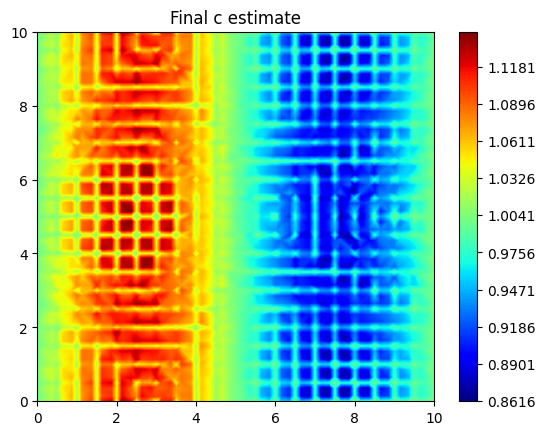

In [46]:
plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 2.880685244455428e-05
Wave speed (c) error: 0.002910287738674041
||dedc||: 0.00361391000430783
CPU times: user 1min 31s, sys: 1min 38s, total: 3min 9s
Wall time: 26.2 s


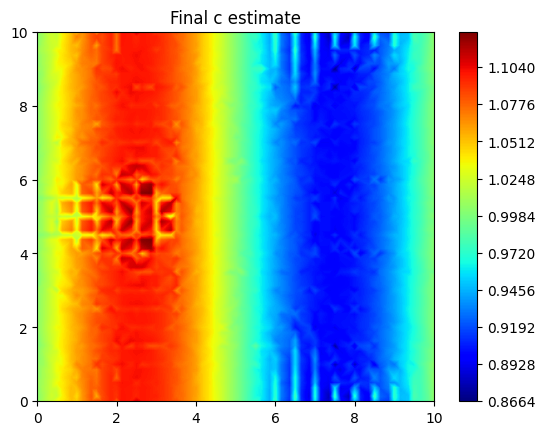

In [47]:
%%time
c_est = optimization_step(c_est, target_state, target_ic, maxiter=100)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 2.607987511737124e-07
Wave speed (c) error: 0.0004055328483904455
||dedc||: 0.00026816579274604926
CPU times: user 2min 45s, sys: 3min 50s, total: 6min 36s
Wall time: 54.9 s


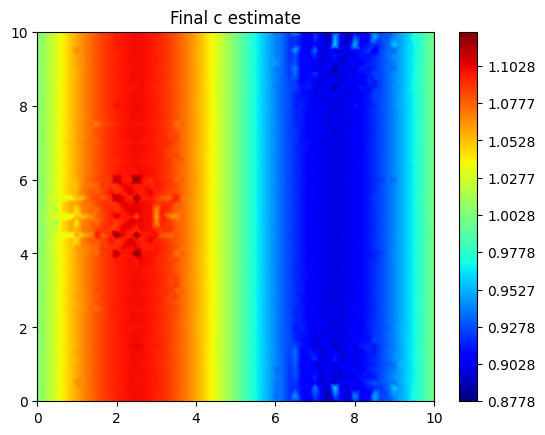

In [48]:
%%time
c_est = optimization_step(c_est, target_state, target_ic, maxiter=200)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 4.575030095610243e-09
Wave speed (c) error: 0.00011772689934227103
||dedc||: 2.8031473255064897e-05
CPU times: user 2min 20s, sys: 4min 20s, total: 6min 40s
Wall time: 54.9 s


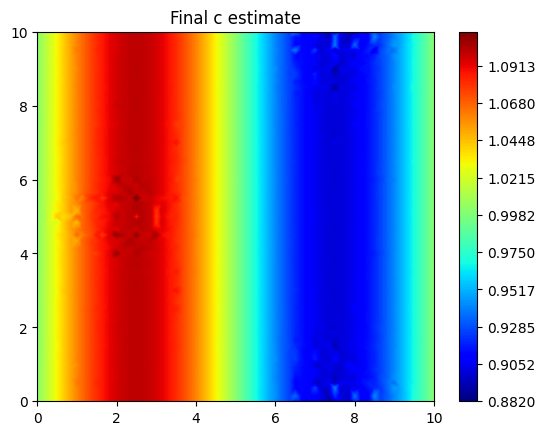

In [49]:
%%time
c_est = optimization_step(c_est, target_state, target_ic, maxiter=200)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()